In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from datasets import load_dataset

ds = load_dataset("tranthaihoa/vifactcheck")

README.md:   0%|          | 0.00/853 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/8.07M [00:00<?, ?B/s]

data/dev-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/2.48M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5062 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/723 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1447 [00:00<?, ? examples/s]

In [ ]:
ds

DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'index', 'Statement', 'Context', 'annotation_id', 'Topic', 'Author', 'Url', 'labels', 'Evidence'],
        num_rows: 5062
    })
    dev: Dataset({
        features: ['Unnamed: 0', 'index', 'Statement', 'Context', 'annotation_id', 'Topic', 'Author', 'Url', 'labels', 'Evidence'],
        num_rows: 723
    })
    test: Dataset({
        features: ['Unnamed: 0', 'index', 'Statement', 'Context', 'annotation_id', 'Topic', 'Author', 'Url', 'labels', 'Evidence'],
        num_rows: 1447
    })
})

In [ ]:
test_df = ds['test'].to_pandas()

In [ ]:
import pandas as pd

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [ ]:
test_df[['Statement', 'Evidence', 'labels']].head()

,Statement,Evidence,labels
0,Bộ xương bản sao được đưa đến Lodon bằng cách nghép thành con hoàn chỉnh rồi vận chuyển đến.,"đại diện Bảo tàng Lịch sử tự nhiên London cho biết bộ xương bản sao đã được đưa đến London trong 32 thùng riêng biệt, nghĩa là ""mỗi mảnh phải được ghép lại với nhau như một trò chơi ghép hình khổng lồ"".",1
1,"Phần vỏ bánh được làm rất công phu, từ giai đoạn xay gạo đến cuốn bánh hết tổng 4 tiếng đồng hồ.","Gạo tẻ ngon được xay nhuyễn bằng cối đá từ xưa, sau đó loại bỏ tạp chất bằng cách lọc qua nước để lấy bột nõn. Đây là công thức từ thời mẹ ông để lại và vẫn được ông duy trì những năm qua. Khách đến gọi mới được phục vụ. Bột tráng bánh được múc theo từng muôi rưới lên mặt nồi hấp, tráng đều rồi đậy vung. Hấp khoảng một phút vỏ bánh vừa chín tới, có độ dai nhẹ. Ông Chính dùng que tre dẹt cuốn lấy vỏ bánh đặt lên đĩa, cho phần nhân đã được xào chín vào rồi cẩn thận cuộn tròn sao cho vỏ không bị rách, cắt đôi và rắc thêm chút hành khô.",2
2,Đối tượng cố gắng bỏ chạy sau khi lực lượng công an đón dừng xe để kiểm tra.,"Khi lực lượng công an đón dừng xe để kiểm tra, Thành đã tăng tốc độ để bỏ chạy và va chạm với một xe ô tô khác đi ngược chiều",0
3,"Vì lượng mưa khổng lồ do cơn bão tạo ra đã dẫn đến nhiều vụ sạt lở và ngập lụt, miền nam Mozambique nhận lượng mưa cao hơn gấp đôi hàng năm, và dự kiến nếu bão cứ tiếp tục độ bổ thì lượng mưa tại đây sẽ cao nhất trong lịch sử từ trước đến giờ.","Cơn bão trút lượng mưa khổng lồ xuống đất liền, dẫn tới nhiều vụ sạt lở và ngập lụt Miền nam Mozambique nhận lượng mưa cao hơn gấp đôi hàng năm",2
4,"Tại một địa điểm trên địa bàn huyện Củ Chi, TPHCM, Công an đã phát hiện hai nghi phạm có liên quan đến vụ việc là N. được xác định là mẹ ruột bé Th. và B. là người đàn ông xăm trổ xuất hiện trong video clip được lan truyền những ngày gần đây với nội dung bạo hành.","N. được xác định là mẹ ruột của bé Th. B. chính là người đàn ông xăm trổ trong các clip lan truyền trên mạng xã hội về nội dung bạo hành Công an đã phát hiện B. và N. tại một địa điểm trên địa bàn huyện Củ Chi, TPHCM.",0


In [ ]:
import pandas as pd
import numpy as np

def process_dataset(csv_path, jsonl_path, hf_data, output_filename):
    """
    Process and combine data from CSV, JSONL, and Hugging Face dataset split into a TSV file.

    Args:
        csv_path (str): Path to the CSV file.
        jsonl_path (str): Path to the JSONL file.
        hf_data (Dataset): Hugging Face dataset object (e.g., ds['train']).
        output_filename (str): Name of the output TSV file.

    Returns:
        str: The output filename.
    """
    # Load the CSV file
    df_csv = pd.read_csv(csv_path)

    # Process the CSV data
    df_csv_processed = df_csv[['context', 'evidence', 'claim']].copy()
    df_csv_processed.rename(columns={'claim': 'query', 'context': 'document'}, inplace=True)

    # Load the JSONL file
    df_jsonl = pd.read_json(jsonl_path, lines=True)

    # Process the JSONL data
    # Identify evidence columns (using the typo "envidence" found during inspection)
    evidence_cols = ['envidence 1', 'envidence 2', 'envidence 3', 'envidence 4']

    # Fill NaN with empty strings to allow for concatenation
    df_jsonl[evidence_cols] = df_jsonl[evidence_cols].fillna('')

    # Concatenate evidence columns into a single 'document' column
    df_jsonl['evidence'] = df_jsonl[evidence_cols].apply(lambda row: ' '.join(row.values.astype(str)), axis=1)

    # Select and rename the 'claim' column to 'query'
    df_jsonl_processed = df_jsonl[[ 'context', 'evidence', 'claim']].copy()
    df_jsonl_processed.rename(columns={'claim': 'query', 'context': 'document'}, inplace=True)

    # Process Hugging Face dataset split
    hf_df = hf_data.to_pandas()
    df_vifactcheck_processed = hf_df.rename(columns={'Statement': 'query', 'Evidence': 'evidence', 'Context': 'document'})[['document', 'evidence', 'query']]

    # Combine the two processed DataFrames
    df_combined = pd.concat([df_vifactcheck_processed, df_csv_processed, df_jsonl_processed], ignore_index=True)

    # --- Clean and format the combined data ---

    # Ensure both columns are string type
    df_combined['document'] = df_combined['document'].astype(str)
    df_combined['query'] = df_combined['query'].astype(str)
    df_combined['evidence'] = df_combined['evidence'].astype(str)

    # Remove any leading/trailing whitespace
    df_combined['document'] = df_combined['document'].str.strip()
    df_combined['query'] = df_combined['query'].str.strip()
    df_combined['evidence'] = df_combined['evidence'].str.strip()

    # Replace 'nan' strings (from explicit conversion) and other non-text placeholders with empty strings
    # This handles cases where 'document' might have just been "NaN NaN NaN NaN"
    df_combined.replace(['nan', np.nan, 'None'], '', inplace=True)

    # Re-strip whitespace after replacements
    df_combined['document'] = df_combined['document'].str.strip()
    df_combined['query'] = df_combined['query'].str.strip()
    df_combined['evidence'] = df_combined['evidence'].str.strip()

    # Drop rows where either 'document' or 'query' is an empty string
    df_combined.drop(df_combined[(df_combined['document'] == '') | (df_combined['query'] == '') | (df_combined['evidence'] == '')].index, inplace=True)

    # Drop duplicate pairs
    df_combined.drop_duplicates(inplace=True)

    # --- Verify and Save ---

    # Print head and shape for verification
    print(f"--- Combined and Cleaned DataFrame Head ({output_filename}) ---")
    print(df_combined.head())
    print(f"\n--- Combined and Cleaned DataFrame Shape ({output_filename}) ---")
    print(df_combined.shape)

    # Save the output to a TSV file
    df_combined.to_csv(output_filename, index=False)

    print(f"\nSuccessfully created {output_filename}")
    print(f"Total rows in output: {df_combined.shape[0]}")
    print(f"Total columns in output: {df_combined.shape[1]}")

    return output_filename

In [ ]:
# Execute the function for the training data
process_dataset(
    csv_path="/content/drive/MyDrive/KLTN_Project/Datasets/ViWikiFC/train_final_pro.csv",
    jsonl_path="/content/drive/MyDrive/KLTN_Project/Datasets/ViNumFCR/Data_10008_gốc/train_evidence.jsonl",
    hf_data=ds['train'],
    output_filename="/content/drive/MyDrive/KLTN_Project/Datasets/vifc_train.csv"
)

--- Combined and Cleaned DataFrame Head (/content/drive/MyDrive/KLTN_Project/Datasets/vifc_train.csv) ---
                                            document  \
0  (Chinhphu.vn) - Đây là mong muốn, gửi gắm của ...   
1  Ngày 24/3, Cơ quan Cảnh sát điều tra Công an t...   
2  (PLO)- Theo Tổng Công ty Cấp nước Sài Gòn (SAW...   
3  Với khoảng 200 thành viên, UEF Warm Hugs Club ...   
4  Đi qua 2 năm dịch bệnh đầy thử thách, nhưng ch...   

                                            evidence  \
0  Thay mặt Chính phủ, Thủ tướng Chính phủ, Phó T...   
1  Tô Văn Hải đã có hành vi cho phép người khác đ...   
2  SAWACO thông báo tạm ngưng cung cấp nước để th...   
3  Là chương trình lớn nhất của CLB trong năm nên...   
4  Bé được tham gia kiểm tra trình độ đầu vào, tư...   

                                               query  
0  Phó Thủ tướng Trần Hồng Hà thay mặt Chính phủ,...  
1  Hành vi của Tô Văn Hải là cho phép người khác ...  
2  SAWACO thông báo tạm ngưng cung cấp nước để th...  


'/content/drive/MyDrive/KLTN_Project/Datasets/vifc_train.csv'

In [ ]:
process_dataset(
    csv_path="/content/drive/MyDrive/KLTN_Project/Datasets/ViWikiFC/dev_final_pro.csv",
    jsonl_path="/content/drive/MyDrive/KLTN_Project/Datasets/ViNumFCR/Data_10008_gốc/dev_evidence.jsonl",
    hf_data=ds['dev'],
    output_filename="/content/drive/MyDrive/KLTN_Project/Datasets/vifc_dev.csv"
)

--- Combined and Cleaned DataFrame Head (/content/drive/MyDrive/KLTN_Project/Datasets/vifc_dev.csv) ---
                                            document  \
0  Saigon Morin, khách sạn 4 sao hàng đầu tại Huế...   
1  (Chinhphu.vn) - Bí thư Trung ương Đảng, Trưởng...   
2  (NLĐO)- Sau khi mua khoản nợ từ Công ty Mirae ...   
3  Gen Alpha (Thế hệ Alpha) được xem là những 'co...   
4  (Chinhphu.vn) - Đây là yêu cầu của Phó Thủ tướ...   

                                            evidence  \
0  Vua hề Charlie Chaplin (vua hề Sác lô) và vợ t...   
1  Việc mua, đọc, sử dụng báo, tạp chí của Đảng t...   
2  Công ty TNHH Mua bán nợ DSP, địa chỉ: Tầng 4, ...   
3  Đây là thế hệ được sinh ra trong thời đại công...   
4  Sức chứa của hệ thống kho khí hóa lỏng (LPG) c...   

                                               query  
0  Vào tháng 4.1930 TL Nhà vua Na Uy Harald V, Vu...  
1  Nhiều chi bộ chỉ mua báo đảng mà không quan tâ...  
2  Công ty TNHH Mua bán nợ DSP, địa chỉ  91 Paste...  
3 

'/content/drive/MyDrive/KLTN_Project/Datasets/vifc_dev.csv'

In [ ]:
process_dataset(
    csv_path="/content/drive/MyDrive/KLTN_Project/Datasets/ViWikiFC/test_final_pro.csv",
    jsonl_path="/content/drive/MyDrive/KLTN_Project/Datasets/ViNumFCR/Data_10008_gốc/test_evidence.jsonl",
    hf_data=ds['test'],
    output_filename="/content/drive/MyDrive/KLTN_Project/Datasets/vifc_test.csv"
)

--- Combined and Cleaned DataFrame Head (/content/drive/MyDrive/KLTN_Project/Datasets/vifc_test.csv) ---
                                            document  \
0  Bản sao bộ xương hóa thạch của một trong những...   
1  Bánh cuốn Thụy Khuê là quán ăn đã qua hai đời,...   
2  (PLO)- Khi lực lượng công an đón dừng xe để ki...   
3  Bão Freddy tàn phá đông nam châu Phi đã di chu...   
4  (Chinhphu.vn) - Dù có phải là hành vi ép buộc ...   

                                            evidence  \
0  đại diện Bảo tàng Lịch sử tự nhiên London cho ...   
1  Gạo tẻ ngon được xay nhuyễn bằng cối đá từ xưa...   
2  Khi lực lượng công an đón dừng xe để kiểm tra,...   
3  Cơn bão trút lượng mưa khổng lồ xuống đất liền...   
4  N. được xác định là mẹ ruột của bé Th. B. chín...   

                                               query  
0  Bộ xương bản sao được đưa đến Lodon bằng cách ...  
1  Phần vỏ bánh được làm rất công phu, từ giai đo...  
2  Đối tượng cố gắng bỏ chạy sau khi lực lượng cô...  
3

'/content/drive/MyDrive/KLTN_Project/Datasets/vifc_test.csv'

In [ ]:
dev_vifc = pd.read_csv("/content/drive/MyDrive/KLTN_Project/Datasets/vifc_dev.csv")
test_vifc = pd.read_csv("/content/drive/MyDrive/KLTN_Project/Datasets/vifc_test.csv")

combined_test_vifc = pd.concat([dev_vifc, test_vifc], ignore_index=True)
combined_test_vifc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7687 entries, 0 to 7686
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   document  7687 non-null   object
 1   evidence  7687 non-null   object
 2   query     7687 non-null   object
dtypes: object(3)
memory usage: 180.3+ KB


In [ ]:
combined_test_vifc.to_csv('/content/drive/MyDrive/KLTN_Project/Datasets/vifc_test_set.csv')

In [ ]:
combined_vifc = pd.read_csv("/content/drive/MyDrive/KLTN_Project/Datasets/vifc.csv")
combined_vifc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34811 entries, 0 to 34810
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  34811 non-null  int64 
 1   document    34811 non-null  object
 2   evidence    34811 non-null  object
 3   query       34811 non-null  object
 4   id          34811 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 1.3+ MB


In [ ]:
import pandas as pd

# 1. Generate Unique Document Mapping
unique_docs = combined_vifc['document'].unique()
# Create a DataFrame with generated IDs
doc_mapping = pd.DataFrame({
    'doc_id': range(len(unique_docs)),
    'document': unique_docs
})

# 2. Generate Unique Query Mapping
unique_queries = combined_vifc['query'].unique()
# Create a DataFrame with generated IDs
query_mapping = pd.DataFrame({
    'query_id': range(len(unique_queries)),
    'query': unique_queries
})

# Define output paths
doc_mapping_path = '/content/drive/MyDrive/KLTN_Project/Datasets/unique_doc_mapping.csv'
query_mapping_path = '/content/drive/MyDrive/KLTN_Project/Datasets/unique_query_mapping.csv'

# Save mappings to CSV
doc_mapping.to_csv(doc_mapping_path, index=False)
query_mapping.to_csv(query_mapping_path, index=False)

# Display information
print(f"--- Document Mapping ---")
print(f"Saved to: {doc_mapping_path}")
print(f"Unique Documents: {len(doc_mapping)}")
display(doc_mapping.head())

print(f"\n--- Query Mapping ---")
print(f"Saved to: {query_mapping_path}")
print(f"Unique Queries: {len(query_mapping)}")
display(query_mapping.head())

--- Document Mapping ---
Saved to: /content/drive/MyDrive/KLTN_Project/Datasets/unique_doc_mapping.csv
Unique Documents: 3030


,doc_id,document
0,0,"(Chinhphu.vn) - Đây là mong muốn, gửi gắm của ..."
1,1,"Ngày 24/3, Cơ quan Cảnh sát điều tra Công an t..."
2,2,(PLO)- Theo Tổng Công ty Cấp nước Sài Gòn (SAW...
3,3,"Với khoảng 200 thành viên, UEF Warm Hugs Club ..."
4,4,"Đi qua 2 năm dịch bệnh đầy thử thách, nhưng ch..."



--- Query Mapping ---
Saved to: /content/drive/MyDrive/KLTN_Project/Datasets/unique_query_mapping.csv
Unique Queries: 34703


,query_id,query
0,0,"Phó Thủ tướng Trần Hồng Hà thay mặt Chính phủ,..."
1,1,Hành vi của Tô Văn Hải là cho phép người khác ...
2,2,SAWACO thông báo tạm ngưng cung cấp nước để th...
3,3,"CLB luôn chuẩn bị rất kỹ lưỡng, chỉn chu chươn..."
4,4,"ILA tiếp nhận và hỗ trợ học sinh miễn phí, Bé ..."


In [ ]:
import csv
import json
import os

def add_jsonl_queries_to_csv(csv_path, jsonl_path, output_path):
    """
    Reads a CSV of existing queries and a JSONL of new query triples.
    Adds unique queries from JSONL to the CSV with new incrementing IDs.
    """

    # Dictionary to store query -> id mapping (ensures uniqueness)
    # and a list to keep the original order for existing items
    query_map = {}
    current_data = []
    max_id = -1

    print(f"Reading existing CSV: {csv_path}...")

    try:
        with open(csv_path, mode='r', encoding='utf-8', newline='') as csvfile:
            reader = csv.DictReader(csvfile)

            # Verify headers
            if 'query_id' not in reader.fieldnames or 'query' not in reader.fieldnames:
                raise ValueError("CSV file must contain 'query_id' and 'query' columns.")

            for row in reader:
                try:
                    qid = int(row['query_id'])
                    query_text = row['query'].strip()

                    if query_text not in query_map:
                        query_map[query_text] = qid
                        current_data.append({'query_id': qid, 'query': query_text})

                    if qid > max_id:
                        max_id = qid
                except ValueError:
                    print(f"Skipping malformed row: {row}")
                    continue

        print(f"Loaded {len(current_data)} existing queries. Max ID is {max_id}.")

    except FileNotFoundError:
        print("CSV file not found. Creating a new mapping starting from ID 0.")
        max_id = -1

    print(f"Processing JSONL file: {jsonl_path}...")

    new_count = 0
    with open(jsonl_path, mode='r', encoding='utf-8') as jsonlfile:
        for line_number, line in enumerate(jsonlfile):
            if not line.strip():
                continue

            try:
                data = json.loads(line)
                # The JSONL contains a list of generated queries under 'generated_queries'
                generated_queries = data.get('generated_queries', [])

                for item in generated_queries:
                    # Extract the query text
                    new_query = item.get('query', '').strip()

                    # If valid and not already in our map, add it
                    if new_query and new_query not in query_map:
                        max_id += 1
                        query_map[new_query] = max_id
                        current_data.append({'query_id': max_id, 'query': new_query})
                        new_count += 1

            except json.JSONDecodeError:
                print(f"Warning: Could not parse JSON on line {line_number + 1}")

    print(f"Found {new_count} new unique queries.")
    print(f"Writing updated data to: {output_path}...")

    # Write the updated data to the output CSV
    with open(output_path, mode='w', encoding='utf-8', newline='') as outfile:
        fieldnames = ['query_id', 'query']
        writer = csv.DictWriter(outfile, fieldnames=fieldnames, quoting=csv.QUOTE_MINIMAL)

        writer.writeheader()
        for row in current_data:
            writer.writerow(row)

    print("Done successfully.")

# --- Configuration ---
input_csv = '/content/drive/MyDrive/KLTN_Project/Datasets/unique_query_mapping.csv'
input_jsonl = '/content/drive/MyDrive/KLTN_Project/Datasets/vifc_queries_triples.jsonl'
output_csv = '/content/drive/MyDrive/KLTN_Project/Datasets/updated_unique_query_mapping.csv'

In [ ]:
add_jsonl_queries_to_csv(input_csv, input_jsonl, output_csv)

Reading existing CSV: /content/drive/MyDrive/KLTN_Project/Datasets/unique_query_mapping.csv...
Loaded 34703 existing queries. Max ID is 34702.
Processing JSONL file: /content/drive/MyDrive/KLTN_Project/Datasets/vifc_queries_triples.jsonl...
Found 102003 new unique queries.
Writing updated data to: /content/drive/MyDrive/KLTN_Project/Datasets/updated_unique_query_mapping.csv...
Done successfully.


In [ ]:
import pandas as pd

# Read the test dataset
df_test = pd.read_csv('/content/drive/MyDrive/KLTN_Project/Datasets/vifc_test_set.csv')

# Read the updated query mapping
df_query_mapping = pd.read_csv('/content/drive/MyDrive/KLTN_Project/Datasets/updated_unique_query_mapping.csv')

# Verify df_test
print("--- df_test ---")
print(df_test.head())
print(df_test.shape)

# Verify df_query_mapping
print("\n--- df_query_mapping ---")
print(df_query_mapping.head())
print(df_query_mapping.shape)

--- df_test ---
   Unnamed: 0                                           document  \
0           0  Saigon Morin, khách sạn 4 sao hàng đầu tại Huế...   
1           1  (Chinhphu.vn) - Bí thư Trung ương Đảng, Trưởng...   
2           2  (NLĐO)- Sau khi mua khoản nợ từ Công ty Mirae ...   
3           3  Gen Alpha (Thế hệ Alpha) được xem là những 'co...   
4           4  (Chinhphu.vn) - Đây là yêu cầu của Phó Thủ tướ...   

                                            evidence  \
0  Vua hề Charlie Chaplin (vua hề Sác lô) và vợ t...   
1  Việc mua, đọc, sử dụng báo, tạp chí của Đảng t...   
2  Công ty TNHH Mua bán nợ DSP, địa chỉ: Tầng 4, ...   
3  Đây là thế hệ được sinh ra trong thời đại công...   
4  Sức chứa của hệ thống kho khí hóa lỏng (LPG) c...   

                                               query  
0  Vào tháng 4.1930 TL Nhà vua Na Uy Harald V, Vu...  
1  Nhiều chi bộ chỉ mua báo đảng mà không quan tâ...  
2  Công ty TNHH Mua bán nợ DSP, địa chỉ  91 Paste...  
3  Bởi được sinh r

In [ ]:
# Identify queries present in the test set
test_queries = set(df_test['query'].unique())

# Split df_query_mapping into test and train mappings
test_query_mapping = df_query_mapping[df_query_mapping['query'].isin(test_queries)].copy()
train_query_mapping = df_query_mapping[~df_query_mapping['query'].isin(test_queries)].copy()

# Define output paths
test_mapping_path = '/content/drive/MyDrive/KLTN_Project/Datasets/test_query_mapping.csv'
train_mapping_path = '/content/drive/MyDrive/KLTN_Project/Datasets/train_query_mapping.csv'

# Save the DataFrames to CSV
test_query_mapping.to_csv(test_mapping_path, index=False)
train_query_mapping.to_csv(train_mapping_path, index=False)

# Display information
print(f"--- Test Query Mapping ---")
print(f"Saved to: {test_mapping_path}")
print(f"Shape: {test_query_mapping.shape}")
print(test_query_mapping.head())

print(f"\n--- Train Query Mapping ---")
print(f"Saved to: {train_mapping_path}")
print(f"Shape: {train_query_mapping.shape}")
print(train_query_mapping.head())

--- Test Query Mapping ---
Saved to: /content/drive/MyDrive/KLTN_Project/Datasets/test_query_mapping.csv
Shape: (7685, 2)
      query_id                                              query
2216      2216  Đây là vụ hoả hoạn nghiêm trọng thứ ba trong l...
2640      2640  Thảm hoạ cháy kho do sét đánh trúng bể dầu ở C...
5615      5615  Tiếng Pháp là ngôn ngữ chính thức của tất cả c...
6124      6124  Nouvelle-Calédonie và Polynésie là 2 khu vực l...
7104      7104  Việt Nam tuyên bố chủ quyền đối với hai thực t...

--- Train Query Mapping ---
Saved to: /content/drive/MyDrive/KLTN_Project/Datasets/train_query_mapping.csv
Shape: (129021, 2)
   query_id                                              query
0         0  Phó Thủ tướng Trần Hồng Hà thay mặt Chính phủ,...
1         1  Hành vi của Tô Văn Hải là cho phép người khác ...
2         2  SAWACO thông báo tạm ngưng cung cấp nước để th...
3         3  CLB luôn chuẩn bị rất kỹ lưỡng, chỉn chu chươn...
4         4  ILA tiếp nhận và hỗ trợ học

# Attach label

In [ ]:
import pandas as pd
import numpy as np
from datasets import load_dataset

def regenerate_labeled_test_set(
    hf_dataset,
    dev_csv_path,
    test_csv_path,
    dev_jsonl_path,
    test_jsonl_path,
    output_path
):
    """
    Regenerates the complete test set (combining dev + test splits) from raw sources,
    including the unified labels from the start to avoid matching errors.

    Unified Label Format: "Supported", "Refuted", "Not Enough Information"
    """

    # List to hold all processed dataframes before concatenation
    all_dfs = []

    # --- Helper: Standardize and Clean Data ---
    def standard_clean(df, label_map):
        # Map labels
        df['label'] = df['label_orig'].map(label_map).fillna(df['label_orig'])

        # Select and order columns
        df = df[['document', 'evidence', 'query', 'label']]

        # Ensure all text columns are strings and stripped of whitespace
        for col in ['document', 'evidence', 'query']:
            df[col] = df[col].astype(str).str.strip().replace(['nan', 'None', 'NaN'], '')

        return df

    # ==========================================
    # 1. Process Hugging Face Data (Dev + Test)
    # ==========================================
    print("Processing Hugging Face datasets...")
    hf_label_map = {0: "Supported", 1: "Refuted", 2: "Not Enough Information"}

    for split in ['dev', 'test']:
        df = hf_dataset[split].to_pandas()
        df = df.rename(columns={
            'Statement': 'query',
            'Evidence': 'evidence',
            'Context': 'document',
            'labels': 'label_orig'
        })
        all_dfs.append(standard_clean(df, hf_label_map))

    # ==========================================
    # 2. Process CSV Data (Dev + Test)
    # ==========================================
    print("Processing CSV datasets...")
    csv_label_map = {
        "Supports": "Supported",
        "Refutes": "Refuted",
        "Not_Enough_Information": "Not Enough Information"
    }

    for path in [dev_csv_path, test_csv_path]:
        df = pd.read_csv(path)
        df = df.rename(columns={
            'claim': 'query',
            'context': 'document',
            'gold_label': 'label_orig'
        })
        # CSV processing already has 'evidence', so we just pass it
        all_dfs.append(standard_clean(df, csv_label_map))

    # ==========================================
    # 3. Process JSONL Data (Dev + Test)
    # ==========================================
    print("Processing JSONL datasets...")
    jsonl_label_map = {
        "Supported": "Supported",
        "Refuted": "Refuted",
        "NotenoughInfo": "Not Enough Information"
    }

    for path in [dev_jsonl_path, test_jsonl_path]:
        df = pd.read_json(path, lines=True)

        # Robustly handle evidence columns (fixing the specific bug from before)
        # We capture ALL columns containing 'envidence' (including typos in source)
        evidence_cols = [c for c in df.columns if 'envidence' in c]
        if evidence_cols:
            # Fill NaNs with empty string and join them
            df[evidence_cols] = df[evidence_cols].fillna('')
            df['evidence'] = df[evidence_cols].apply(lambda row: ' '.join(row.values.astype(str)).strip(), axis=1)

        df = df.rename(columns={
            'claim': 'query',
            'context': 'document',
            'label': 'label_orig'
        })
        all_dfs.append(standard_clean(df, jsonl_label_map))

    # ==========================================
    # 4. Concatenate, Clean, and Save
    # ==========================================
    print("combining all data...")
    final_df = pd.concat(all_dfs, ignore_index=True)

    # Remove rows where crucial data is empty
    initial_len = len(final_df)
    final_df = final_df[
        (final_df['document'] != '') &
        (final_df['query'] != '') &
        (final_df['evidence'] != '')
    ]

    # Drop exact duplicates
    final_df = final_df.drop_duplicates()

    print(f"Dropped {initial_len - len(final_df)} empty/duplicate rows.")

    # Verification: Check for missing labels
    missing = final_df['label'].isnull().sum()
    if missing > 0:
        print(f"WARNING: {missing} rows still have no label.")
    else:
        print("SUCCESS: All rows have labels.")

    # Save
    print(f"Saving to {output_path}...")
    final_df.to_csv(output_path, index=False)

    print(f"Final Shape: {final_df.shape}")
    print("Label Distribution:")
    print(final_df['label'].value_counts())

    return final_df

# --- Execute ---
df_labeled = regenerate_labeled_test_set(
    hf_dataset=ds,
    dev_csv_path="/content/drive/MyDrive/KLTN_Project/Datasets/ViWikiFC/dev_final_pro.csv",
    test_csv_path="/content/drive/MyDrive/KLTN_Project/Datasets/ViWikiFC/test_final_pro.csv",
    dev_jsonl_path="/content/drive/MyDrive/KLTN_Project/Datasets/ViNumFCR/Data_10008_gốc/dev_evidence.jsonl",
    test_jsonl_path="/content/drive/MyDrive/KLTN_Project/Datasets/ViNumFCR/Data_10008_gốc/test_evidence.jsonl",
    output_path='/content/drive/MyDrive/KLTN_Project/Datasets/vifc_test_set_with_labels.csv'
)

Processing Hugging Face datasets...
Processing CSV datasets...


/tmp/ipython-input-3892411853.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].astype(str).str.strip().replace(['nan', 'None', 'NaN'], '')
/tmp/ipython-input-3892411853.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].astype(str).str.strip().replace(['nan', 'None', 'NaN'], '')
/tmp/ipython-input-3892411853.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

Processing JSONL datasets...


/tmp/ipython-input-3892411853.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].astype(str).str.strip().replace(['nan', 'None', 'NaN'], '')
/tmp/ipython-input-3892411853.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].astype(str).str.strip().replace(['nan', 'None', 'NaN'], '')
/tmp/ipython-input-3892411853.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

combining all data...
Dropped 668 empty/duplicate rows.
SUCCESS: All rows have labels.
Saving to /content/drive/MyDrive/KLTN_Project/Datasets/vifc_test_set_with_labels.csv...
Final Shape: (7687, 4)
Label Distribution:
label
Supported                 2806
Refuted                   2780
Not Enough Information    2101
Name: count, dtype: int64


In [ ]:
label_df = pd.read_csv('/content/drive/MyDrive/KLTN_Project/Datasets/vifc_test_set_with_labels.csv')

In [ ]:
label_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7687 entries, 0 to 7686
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   document  7687 non-null   object
 1   evidence  7687 non-null   object
 2   query     7687 non-null   object
 3   label     7687 non-null   object
dtypes: object(4)
memory usage: 240.3+ KB


# Additional EDA

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set plot style for consistency
sns.set(style="whitegrid", palette="muted")

def plot_source_distribution(csv_paths, jsonl_paths, hf_dataset):
    """
    Calculates and plots the distribution of the 3 source datasets:
    ViWikiFC (CSV), ViNumFCR (JSONL), and ViFactCheck (Hugging Face).

    Args:
        csv_paths (list): List of file paths for ViWikiFC CSV files (train/dev/test).
        jsonl_paths (list): List of file paths for ViNumFCR JSONL files (train/dev/test).
        hf_dataset (DatasetDict): The loaded Hugging Face dataset (ViFactCheck).
    """
    counts = {}

    # 1. Count ViWikiFC (CSVs)
    print("Counting ViWikiFC samples...")
    viwikifc_count = 0
    for path in csv_paths:
        try:
            # Only reading one column is enough to count rows and faster
            df = pd.read_csv(path, usecols=[0])
            viwikifc_count += len(df)
        except Exception as e:
            print(f"Error reading {path}: {e}")
    counts['ViWikiFC'] = viwikifc_count

    # 2. Count ViNumFCR (JSONLs)
    print("Counting ViNumFCR samples...")
    vinumfcr_count = 0
    for path in jsonl_paths:
        try:
            # chunks or line counting is safer for large jsonl, but pandas is fine here
            df = pd.read_json(path, lines=True)
            vinumfcr_count += len(df)
        except Exception as e:
            print(f"Error reading {path}: {e}")
    counts['ViNumFCR'] = vinumfcr_count

    # 3. Count ViFactCheck (Hugging Face)
    print("Counting ViFactCheck samples...")
    vifactcheck_count = 0
    for split in hf_dataset.keys():
        vifactcheck_count += len(hf_dataset[split])
    counts['ViFactCheck'] = vifactcheck_count

    # --- Plotting ---
    data = pd.DataFrame(list(counts.items()), columns=['Dataset', 'Count'])

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x='Dataset', y='Count', data=data, palette="viridis")

    # Add labels
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontweight='bold')

    plt.title('Total Distribution of Source Datasets (Train + Dev + Test)')
    plt.ylabel('Number of Samples')
    plt.show()

    return counts

In [4]:
def plot_test_label_distribution(df):
    """
    Plots the distribution of labels in the provided DataFrame (Test set).
    Assumes 'label' column exists with values like 'Supported', 'Refuted', etc.
    """
    # Calculate counts
    label_counts = df['label'].value_counts().reset_index()
    label_counts.columns = ['Label', 'Count']

    plt.figure(figsize=(8, 6))
    ax = sns.barplot(x='Label', y='Count', data=label_counts, palette="Set2")

    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points')

    plt.title('Distribution of Labels in Test Set')
    plt.ylabel('Count')
    plt.show()

In [5]:
def plot_token_length_distribution(df, text_columns=['query', 'document', 'evidence']):
    """
    Plots token length distribution for specific columns and prints max/mean.
    Maps 'query' -> Claim, 'document' -> Context.
    """
    stats = {}

    # Mapping friendly names for the plot
    column_map = {'query': 'Claim', 'document': 'Context', 'evidence': 'Evidence'}

    plt.figure(figsize=(18, 5))

    valid_cols = [c for c in text_columns if c in df.columns]

    for i, col in enumerate(valid_cols):
        # Calculate lengths (approximate using whitespace split)
        lengths = df[col].astype(str).apply(lambda x: len(x.split()))

        # Statistics
        max_len = lengths.max()
        mean_len = lengths.mean()
        stats[col] = {'max': max_len, 'mean': mean_len}

        # Plot
        plt.subplot(1, len(valid_cols), i+1)
        sns.histplot(lengths, kde=True, bins=30, color=sns.color_palette("muted")[i])

        friendly_name = column_map.get(col, col.capitalize())
        plt.title(f'Token Length: {friendly_name}')
        plt.xlabel('Length (tokens)')
        plt.ylabel('Frequency')

        # Add stats box
        plt.text(0.95, 0.95, f"Max: {max_len}\nMean: {mean_len:.1f}",
                 transform=plt.gca().transAxes, ha='right', va='top',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

    plt.tight_layout()
    plt.show()

    return stats

Counting ViWikiFC samples...
Counting ViNumFCR samples...
Counting ViFactCheck samples...


/tmp/ipython-input-2069957325.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Dataset', y='Count', data=data, palette="viridis")


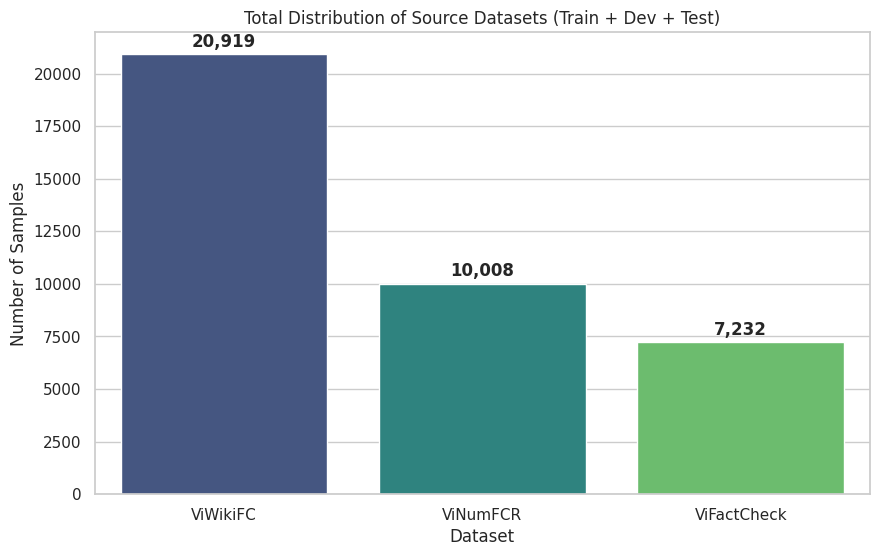

In [7]:
# 1. Define your file paths based on your previous code
csv_files = [
    "/content/drive/MyDrive/KLTN_Project/Datasets/ViWikiFC/train_final_pro.csv",
    "/content/drive/MyDrive/KLTN_Project/Datasets/ViWikiFC/dev_final_pro.csv",
    "/content/drive/MyDrive/KLTN_Project/Datasets/ViWikiFC/test_final_pro.csv"
]

jsonl_files = [
    "/content/drive/MyDrive/KLTN_Project/Datasets/ViNumFCR/Data_10008_gốc/train_evidence.jsonl",
    "/content/drive/MyDrive/KLTN_Project/Datasets/ViNumFCR/Data_10008_gốc/dev_evidence.jsonl",
    "/content/drive/MyDrive/KLTN_Project/Datasets/ViNumFCR/Data_10008_gốc/test_evidence.jsonl"
]

# 2. Run Source Distribution Analysis
# (Assumes 'ds' is already loaded from 'tranthaihoa/vifactcheck')
source_stats = plot_source_distribution(csv_files, jsonl_files, ds)

/tmp/ipython-input-4189489130.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Label', y='Count', data=label_counts, palette="Set2")


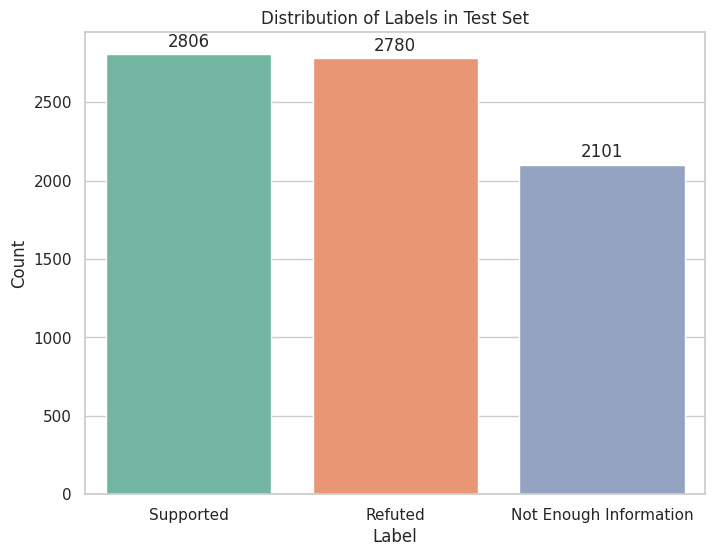

In [8]:
# 3. Load your Labeled Test Set for the remaining plots
# (Using the file you generated in the previous steps)
test_df_labeled = pd.read_csv('/content/drive/MyDrive/KLTN_Project/Datasets/vifc_test_set_with_labels.csv')

# 4. Run Label Distribution
plot_test_label_distribution(test_df_labeled)

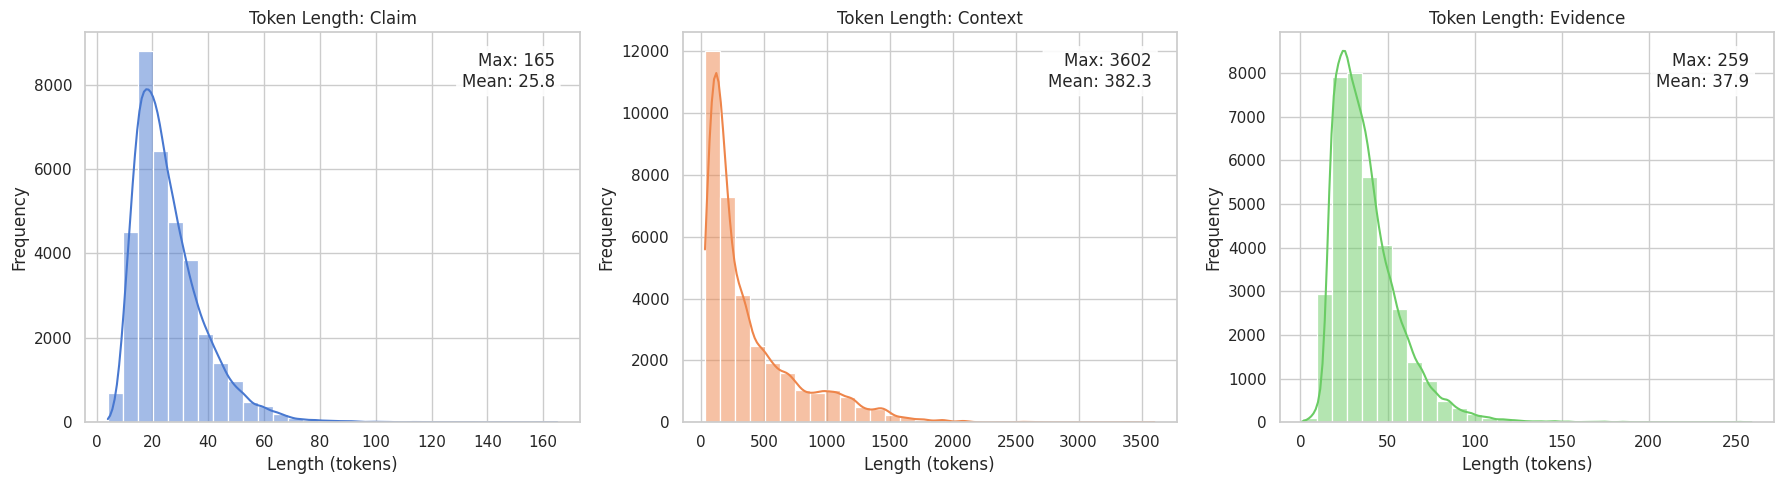

In [10]:
combined_vifc = pd.read_csv('/content/drive/MyDrive/KLTN_Project/Datasets/vifc.csv')

# 5. Run Token Length Distribution
token_stats = plot_token_length_distribution(combined_vifc)